In [4]:
# fifa world cup 2026 goalkeeping analysis
# importing necessary libraries for data analysis and visualization
# Importing pandas for data manipulation and analysis
import pandas as pd

# importing numpy for numerical operations
import numpy as np

# importing json for handling JSON data
import json

# importing matplotlib for data visualization and to create graphs
import matplotlib.pyplot as plt

# importing seaborn for statistical data visualization
import seaborn as sns

# scipy.stats for statistical functions and tests
from scipy import stats

# displaying all columns in pandas DataFrames
pd.set_option('display.max_columns', None)


In [15]:
# loading the dataset

# loading the team squad data from a JSON file into a Python dictionary
with open("team_squads.json", "r", encoding="utf-8") as f:
    team_squads_raw = json.load(f)

# load the player statistics dataset
with open("player_stats.json", "r", encoding="utf-8") as f:
    player_stats_raw = json.load(f)

# load the qualified teams dataset
with open("qualified_teams.json", "r", encoding="utf-8") as f:
    qualified_teams_raw = json.load(f)
# checking the types of the loaded datasets
print("team_squads_raw loaded:", type(team_squads_raw))
print("player_stats_raw loaded:", type(player_stats_raw))
print("qualified_teams_raw loaded:", type(qualified_teams_raw))


team_squads_raw loaded: <class 'list'>
player_stats_raw loaded: <class 'dict'>
qualified_teams_raw loaded: <class 'dict'>


In [18]:
#   Inspecting the structure of the each dataset
# checking the structure of the qualified_teams_raw dataset
print("qualified_teams_raw type:", type(qualified_teams_raw))
# checking the top-level keys in the qualified_teams_raw dataset
print("Top-level keys:", list(qualified_teams_raw.keys()))
# checking the number of entries in the 'Results' key of the qualified_teams_raw dataset
print("Number of entries in 'Results':", len(qualified_teams_raw["Results"]))
# checking the structure of the first entry in the 'Results' key of the qualified_teams_raw dataset 
print()
# displaying an example record from the 'Results' key
print("Example record from 'Results':") 
qualified_teams_raw["Results"][0]

qualified_teams_raw type: <class 'dict'>
Top-level keys: ['ContinuationToken', 'ContinuationHash', 'Results']
Number of entries in 'Results': 48

Example record from 'Results':


{'IdCompetition': '17',
 'IdSeason': '285023',
 'IdStage': None,
 'IdTeam': '43921',
 'IdCountry': 'USA',
 'TeamName': [{'Locale': 'en-GB', 'Description': 'USA'}],
 'TeamType': 1,
 'Properties': {},
 'IsUpdateable': None}

In [19]:
# ---- team_squads.json ----
print("team_squads_raw type:", type(team_squads_raw))
print("Number of team records (top-level list length):", len(team_squads_raw))
print()

# Each element of the list is one team. Confirm that.
example_team = team_squads_raw[0]
print("Type of a single element:", type(example_team))
print("Keys of a single team record:", list(example_team.keys()))
print()
print("Team name of first record:", example_team["TeamName"][0]["Description"])
print("Number of players listed in this team's squad:", len(example_team["Players"]))
print()
print("Example player record (first player of first team):")
example_team["Players"][0]

team_squads_raw type: <class 'list'>
Number of team records (top-level list length): 48

Type of a single element: <class 'dict'>
Keys of a single team record: ['IdCompetition', 'IdSeason', 'IdTeam', 'IdCountry', 'PictureUrl', 'TeamName', 'Players', 'Officials', 'ParticipationStatus', 'Properties', 'IsUpdateable']

Team name of first record: USA
Number of players listed in this team's squad: 26

Example player record (first player of first team):


{'IdTeam': '43921',
 'IdPlayer': '448217',
 'IdSeason': '285023',
 'PlayerName': [{'Locale': 'en-GB', 'Description': 'Matt TURNER'}],
 'ShortName': [{'Locale': 'en-GB', 'Description': 'TURNER'}],
 'TeamType': None,
 'JerseyNum': 1,
 'MatchesPlayed': None,
 'Position': 0,
 'BirthDate': '1994-06-24T00:00:00Z',
 'DebutDate': None,
 'JoinDate': '2022-10-21T00:00:00Z',
 'LeaveDate': '2034-12-31T00:00:00Z',
 'PreferredFoot': None,
 'PictureUrl': None,
 'ThumbnailUrl': None,
 'CompetitionDebut': None,
 'RealPosition': 0,
 'RealPositionSide': 3,
 'Goals': None,
 'RedCards': None,
 'YellowCards': None,
 'MediaContent': [],
 'PositionLocalized': [{'Locale': 'en-GB', 'Description': 'Goalkeeper'}],
 'RealPositionLocalized': [{'Locale': 'en-GB', 'Description': 'Goalkeeper'}],
 'RealPositionSideLocalized': [{'Locale': 'en-GB', 'Description': 'Unknown'}],
 'SpecialStatus': 0,
 'Weight': 79.0,
 'Height': 190.0,
 'IdCountry': 'USA',
 'PlayerPicture': {'Id': '01FB042F-5DE5-41DF-81047445672FDCA5',
  'Pic

In [22]:
# confirming the player statistics dataset structure
n_teams = len(team_squads_raw)
n_players_total = sum(len(team["Players"]) for team in team_squads_raw)
# confirming the number of teams and total number of players across all teams
print(f"Correct number of teams in team_squads.json: {n_teams}")
print(f"Total number of players across all teams: {n_players_total}")



Correct number of teams in team_squads.json: 48
Total number of players across all teams: 1248


In [23]:
# player_stats.json structure inspection
print("player_stats_raw type:", type(player_stats_raw))
print("number of players with statistics records:", len(player_stats_raw))
print()
# displaying an example player statistics record
example_player_id = list(player_stats_raw.keys())[0]
example_entry = player_stats_raw[example_player_id]
# displaying information about the example player
print("Example player ID (dictionary key):", example_player_id)
print("Type of the value stored for that key:", type(example_entry))
# displaying the first few statistics for the example player
print("Number of stat fields recorded for this player:", len(example_entry))
print()
print("First 5 [field, value, flag] triples for this player:")
example_entry[:5]


player_stats_raw type: <class 'dict'>
number of players with statistics records: 1259

Example player ID (dictionary key): 430740
Type of the value stored for that key: <class 'list'>
Number of stat fields recorded for this player: 115

First 5 [field, value, flag] triples for this player:


[['Assists', 4, True],
 ['AttemptAtGoal', 6, True],
 ['AttemptAtGoalAgainstOnTarget', 0, True],
 ['AttemptAtGoalBlocked', 4, True],
 ['AttemptAtGoalFromBallProgression', 0, True]]

In [24]:
# extracting the goalkeeper from team_squads dataset

all_positions = set()
for team in team_squads_raw:
    for player in team["Players"]:
        pos_field = player.get("PositionLocalized")
        if pos_field:
            all_positions.add(pos_field[0]["Description"])

print("Distinct player positions found in team_squads.json:")
# displaying the distinct player positions found in the team_squads dataset
print(sorted(all_positions))



Distinct player positions found in team_squads.json:
['Defender', 'Forward', 'Goalkeeper', 'Midfielder']


In [27]:
# Extract every player whose PositionLocalized description is exactly "Goalkeeper".
goalkeeper_records = []
Iterating through each team and their players to identify goalkeepers
for team in team_squads_raw:
    team_id = team["IdTeam"]
    team_name = team["TeamName"][0]["Description"]
    for player in team["Players"]:
        pos_field = player.get("PositionLocalized")
        position = pos_field[0]["Description"] if pos_field else None

        if position == "Goalkeeper":
            goalkeeper_records.append({
                "IdTeam": team_id,
                "TeamName": team_name,
                "IdPlayer": player["IdPlayer"],
                "PlayerName": player["PlayerName"][0]["Description"],
                "JerseyNum": player.get("JerseyNum"),
                "BirthDate": player.get("BirthDate"),
            })

goalkeepers_df = pd.DataFrame(goalkeeper_records)
print(f"Total goalkeepers identified across all 48 squads: {len(goalkeepers_df)}")
goalkeepers_df.head()

Total goalkeepers identified across all 48 squads: 145


,IdTeam,TeamName,IdPlayer,PlayerName,JerseyNum,BirthDate
0,43921,USA,448217,Matt TURNER,1,1994-06-24T00:00:00Z
1,43921,USA,499913,Matt FREESE,24,1998-09-02T00:00:00Z
2,43921,USA,464546,Chris BRADY,25,2004-03-03T00:00:00Z
3,43899,Canada,441255,Dayne ST. CLAIR,1,1997-05-09T00:00:00Z
4,43899,Canada,331732,Maxime CREPEAU,16,1994-05-11T00:00:00Z


In [28]:
# sanity check: ensure that all goalkeepers are listed
gk_counts_per_team = goalkeepers_df.groupby("TeamName").size().sort_values()
print("Teams with the fewest listed goalkeepers:")
print(gk_counts_per_team.head())
print()
print(f"Number of teams represented among the goalkeepers: {goalkeepers_df['TeamName'].nunique()} (expected 48)")

Teams with the fewest listed goalkeepers:
TeamName
Algeria      3
Argentina    3
Australia    3
Austria      3
Belgium      3
dtype: int64

Number of teams represented among the goalkeepers: 48 (expected 48)


In [30]:
# Convert player_stats_raw (dict of [field, value, flag] triples) into a tidy,
# wide-format DataFrame: one row per player ID, one column per stat field.
player_stats_rows = []

for player_id, stat_triples in player_stats_raw.items():
    row = {"IdPlayer": player_id}
    for field_name, value, _flag in stat_triples:
        row[field_name] = value
    player_stats_rows.append(row)

player_stats_df = pd.DataFrame(player_stats_rows)
print(f"player_stats_df shape: {player_stats_df.shape}")
player_stats_df.head(3)

player_stats_df shape: (1259, 116)


,IdPlayer,Assists,AttemptAtGoal,AttemptAtGoalAgainstOnTarget,AttemptAtGoalBlocked,AttemptAtGoalFromBallProgression,AttemptAtGoalFromCorner,AttemptAtGoalFromCross,AttemptAtGoalFromFreekick,AttemptAtGoalFromFreeKicks,AttemptAtGoalFromOther,AttemptAtGoalFromPass,AttemptAtGoalFromPenalty,AttemptAtGoalFromRebound,AttemptAtGoalInsideThePenaltyArea,AttemptAtGoalInsideThePenaltyAreaOnTarget,AttemptAtGoalOffTarget,AttemptAtGoalOnTarget,AttemptAtGoalOutsideThePenaltyArea,AttemptAtGoalOutsideThePenaltyAreaOnTarget,AttemptedBallProgressions,AttemptedSwitchesOfPlay,AvgSpeed,CompletedBallProgressions,CompletedSwitchesOfPlay,Corners,Crosses,CrossesCompleted,DefensivePressuresApplied,DirectDefensivePressuresApplied,DirectFreeKicks,DirectRedCards,DistanceHighSpeedRunning,DistanceHighSpeedSprinting,DistanceJogging,DistanceLowSpeedSprinting,DistanceWalking,DistributionsCompletedUnderPressure,DistributionsUnderPressure,ForcedTurnovers,FoulsAgainst,FoulsFor,FreeKicks,GKSaves,GKSavesOnTarget,GoalkeeperDefensiveActionsInsidePenaltyArea,GoalkeeperDefensiveActionsOutsidePenaltyArea,GoalkeeperSavePercentage,GoalkeeperSaves,GoalkeeperSavesOnTarget,GoalKicks,Goals,GoalsFromDirectFreeKicks,GoalsInsideThePenaltyArea,GoalsOutsideThePenaltyArea,HeadedAttemptAtGoal,IndirectFreeKicks,IndirectRedCards,LinebreaksAttempted,LinebreaksAttemptedAllLines,LinebreaksAttemptedAttackingAndMidfieldLine,LinebreaksAttemptedAttackingLine,LinebreaksAttemptedAttackingLineCompleted,LinebreaksAttemptedAttackingLineCompletedOnly,LinebreaksAttemptedAttackingLineOnly,LinebreaksAttemptedCompleted,LinebreaksAttemptedDefensiveLine,LinebreaksAttemptedDefensiveLineCompleted,LinebreaksAttemptedDefensiveLineCompletedOnly,LinebreaksAttemptedDefensiveLineOnly,LinebreaksAttemptedMidfieldAndDefensiveLine,LinebreaksAttemptedMidfieldLine,LinebreaksAttemptedMidfieldLineCompleted,LinebreaksAttemptedMidfieldLineCompletedOnly,LinebreaksAttemptedMidfieldLineOnly,LinebreaksAttemptedUnderPressure,LinebreaksCompletedAllLines,LinebreaksCompletedAttackingAndMidfieldLine,LinebreaksCompletedMidfieldAndDefensiveLine,LinebreaksCompletedUnderPressure,MatchesPlayed,NumberOfInvolvements,NumberOfPossessionSequences,NumberOfShotEndingSequences,OffersToReceiveInBehind,OffersToReceiveInBetween,OffersToReceiveInFront,OffersToReceiveInside,OffersToReceiveOutside,OffersToReceiveTotal,Offsides,OwnGoals,Passes,PassesCompleted,Penalties,PenaltiesScored,ReceivedOffersToReceive,ReceptionsBetweenMidfieldAndDefensiveLine,ReceptionsInBehind,ReceptionsUnderDirectPressure,ReceptionsUnderIndirectPressure,ReceptionsUnderNoPressure,ReceptionsUnderPressure,RedCards,SpeedRuns,Sprints,SubstitutionsIn,SubstitutionsOut,TakeOnsCompleted,Threat,ThrowIns,TimePlayed,TopSpeed,TotalDistance,XG,YellowCards
0,430740,4,6,0,4,0.0,0.0,0.0,0.0,0,1.0,5.0,0.0,0.0,4,1,1,1,2,0,33.0,0.0,5.881594,19.0,0.0,1,8,3,156.0,24.0,0,0,6253.209839,947.820000,17920.270020,2963.590027,20919.120361,117.0,163.0,15.0,3,10,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,51.0,3.0,0.0,6.0,3.0,1.0,3.0,29.0,13.0,6.0,3.0,7.0,3.0,32.0,20.0,17.0,26.0,45.0,2.0,0.0,1.0,25.0,6,414.0,181.0,18.0,68.0,100.0,29.0,103.0,94.0,197.0,0,0,165,142,0,0,74.0,86.0,6.0,12.0,119.0,89.0,131.0,0,524.0,225.0,0,5,15.0,5.907343,1,500.459250,33.067619,49004.009277,0.305066,0
1,430605,4,8,0,1,0.0,0.0,0.0,0.0,0,2.0,5.0,1.0,0.0,5,2,3,2,3,0,6.0,4.0,7.160577,2.0,3.0,8,12,2,159.0,15.0,9,0,8919.590332,252.790001,25567.679688,2285.640045,17718.420410,99.0,143.0,37.0,4,7,9,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,1,0,0,73.0,6.0,2.0,15.0,12.0,7.0,7.0,44.0,15.0,5.0,2.0,5.0,4.0,43.0,27.0,22.0,31.0,50.0,3.0,2.0,0.0,30.0,5,459.0,200.0,27.0,56.0,156.0,127.0,258.0,81.0,339.0,0,0,200,161,1,0,116.0,51.0,5.0,7.0,85.0,129.0,92.0,0,739.0,158.0,0,4,0.0,3.309369,0,458.662150,28.908438,54744.119141,1.022333,0
2,403585,3,5,0,1,0.0,0.0,0.0,0.0,0,1.0,4.0,0.0,0.0,2,0,4,0,3,0,12.0,1.0,6.342100,9.0,1.0,14,34,11,75.0,13.0,7,0,6637.369995,624.439968,21798.790039,2620.130035,18616.059082,134.0,183.0,6.0,3,5,7,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0

In [31]:
# Merge goalkeeper identity/team information with their statistics on IdPlayer.
# Use a LEFT merge so we can see, and explicitly check for, any goalkeeper who
# does not have a matching statistics record.
gk_stats_df = goalkeepers_df.merge(player_stats_df, on="IdPlayer", how="left", indicator=True)

n_matched = (gk_stats_df["_merge"] == "both").sum()
n_unmatched = (gk_stats_df["_merge"] == "left_only").sum()
print(f"Goalkeepers successfully matched to a statistics record: {n_matched}")
print(f"Goalkeepers with NO matching statistics record: {n_unmatched}")

gk_stats_df = gk_stats_df.drop(columns="_merge")
gk_stats_df.head()

Goalkeepers successfully matched to a statistics record: 145
Goalkeepers with NO matching statistics record: 0


,IdTeam,TeamName,IdPlayer,PlayerName,JerseyNum,BirthDate,Assists,AttemptAtGoal,AttemptAtGoalAgainstOnTarget,AttemptAtGoalBlocked,AttemptAtGoalFromBallProgression,AttemptAtGoalFromCorner,AttemptAtGoalFromCross,AttemptAtGoalFromFreekick,AttemptAtGoalFromFreeKicks,AttemptAtGoalFromOther,AttemptAtGoalFromPass,AttemptAtGoalFromPenalty,AttemptAtGoalFromRebound,AttemptAtGoalInsideThePenaltyArea,AttemptAtGoalInsideThePenaltyAreaOnTarget,AttemptAtGoalOffTarget,AttemptAtGoalOnTarget,AttemptAtGoalOutsideThePenaltyArea,AttemptAtGoalOutsideThePenaltyAreaOnTarget,AttemptedBallProgressions,AttemptedSwitchesOfPlay,AvgSpeed,CompletedBallProgressions,CompletedSwitchesOfPlay,Corners,Crosses,CrossesCompleted,DefensivePressuresApplied,DirectDefensivePressuresApplied,DirectFreeKicks,DirectRedCards,DistanceHighSpeedRunning,DistanceHighSpeedSprinting,DistanceJogging,DistanceLowSpeedSprinting,DistanceWalking,DistributionsCompletedUnderPressure,DistributionsUnderPressure,ForcedTurnovers,FoulsAgainst,FoulsFor,FreeKicks,GKSaves,GKSavesOnTarget,GoalkeeperDefensiveActionsInsidePenaltyArea,GoalkeeperDefensiveActionsOutsidePenaltyArea,GoalkeeperSavePercentage,GoalkeeperSaves,GoalkeeperSavesOnTarget,GoalKicks,Goals,GoalsFromDirectFreeKicks,GoalsInsideThePenaltyArea,GoalsOutsideThePenaltyArea,HeadedAttemptAtGoal,IndirectFreeKicks,IndirectRedCards,LinebreaksAttempted,LinebreaksAttemptedAllLines,LinebreaksAttemptedAttackingAndMidfieldLine,LinebreaksAttemptedAttackingLine,LinebreaksAttemptedAttackingLineCompleted,LinebreaksAttemptedAttackingLineCompletedOnly,LinebreaksAttemptedAttackingLineOnly,LinebreaksAttemptedCompleted,LinebreaksAttemptedDefensiveLine,LinebreaksAttemptedDefensiveLineCompleted,LinebreaksAttemptedDefensiveLineCompletedOnly,LinebreaksAttemptedDefensiveLineOnly,LinebreaksAttemptedMidfieldAndDefensiveLine,LinebreaksAttemptedMidfieldLine,LinebreaksAttemptedMidfieldLineCompleted,LinebreaksAttemptedMidfieldLineCompletedOnly,LinebreaksAttemptedMidfieldLineOnly,LinebreaksAttemptedUnderPressure,LinebreaksCompletedAllLines,LinebreaksCompletedAttackingAndMidfieldLine,LinebreaksCompletedMidfieldAndDefensiveLine,LinebreaksCompletedUnderPressure,MatchesPlayed,NumberOfInvolvements,NumberOfPossessionSequences,NumberOfShotEndingSequences,OffersToReceiveInBehind,OffersToReceiveInBetween,OffersToReceiveInFront,OffersToReceiveInside,OffersToReceiveOutside,OffersToReceiveTotal,Offsides,OwnGoals,Passes,PassesCompleted,Penalties,PenaltiesScored,ReceivedOffersToReceive,ReceptionsBetweenMidfieldAndDefensiveLine,ReceptionsInBehind,ReceptionsUnderDirectPressure,ReceptionsUnderIndirectPressure,ReceptionsUnderNoPressure,ReceptionsUnderPressure,RedCards,SpeedRuns,Sprints,SubstitutionsIn,SubstitutionsOut,TakeOnsCompleted,Threat,ThrowIns,TimePlayed,TopSpeed,TotalDistance,XG,YellowCards
0,43921,USA,448217,Matt TURNER,1,1994-06-24T00:00:00Z,0,0,0,0,0.0,0.0,0.0,NaN,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,1.0,0.679311,0.0,0.0,0,0,0,0.0,0.0,3,0,211.519989,11.36,1514.159912,15.020000,4187.020020,1.0,3.0,0.0,0,0,4,NaN,NaN,21.0,17.0,0.000000,0,0,4,0,0,0,0,0,1,0,17.0,0.0,6.0,9.0,2.0,2.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,2.0,4.0,0.0,0.0,0.0,0.0,1,57.0,33.0,1.0,0.0,0.0,2.0,1.0,1.0,2.0,0,0,33,24,0,0,2.0,0.0,0.0,0.0,1.0,18.0,1.0,0,20.0,2.0,0,0,0.0,0.045575,0,104.902550,28.311914,5939.080078,0.0,0
1,43921,USA,499913,Matt FREESE,24,1998-09-02T00:00:00Z,0,0,0,0,0.0,0.0,0.0,NaN,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0.0,2.761432,0.0,0.0,0,0,0,0.0,0.0,7,0,295.979996,4.25,5252.469971,62.579998,18499.389648,5.0,11.0,0.0,0,2,9,0.0,0.0,58.0,48.0,2.428571,10,8,21,0,0,0,0,0,2,0,52.0,2.0,11.0,27.0,11.0,8.0,14.0,16.0,2.0,0.0,0.0,0.0,0.0,23.0,5.0,2.0,10.0,11.0,0.0,3.0,0.0,5.0,4,172.0,111.0,7.0,0.0,0.0,15.0,10.0,5.0,15.0,0,0,95,63,0,0,9.0,0.0,0.0,0.0,3.0,50.0,3.0,0,26.0,6.0,0,0,0.0,0.184769,0,419.955933,25.542162,24114.669922,0.0,0
2,43921,USA,464546,Chris BRADY,25,2004-03-03T00:00:00Z,0,0,0,0,0.0,0.0,0.0,NaN,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0.0,0.000000,0.0,0.0,0,0,0,0.0,0.0,0,0,0.000000,0.00,0.000000,0.00

In [32]:
candidate_fields = [
    "MatchesPlayed", "TimePlayed",
    "GoalkeeperSaves", "GoalkeeperSavesOnTarget", "GoalkeeperSavePercentage",
    "GKSaves", "GKSavesOnTarget", "Goals",
]

print(gk_stats_df[candidate_fields].describe(include="all"))
print()
print("Missing values per candidate field:")
print(gk_stats_df[candidate_fields].isna().sum())

       MatchesPlayed  TimePlayed  GoalkeeperSaves  GoalkeeperSavesOnTarget  \
count     145.000000  145.000000       145.000000               145.000000   
mean        1.482759  128.728223         4.365517                 3.772414   
std         2.031363  204.218582         6.573108                 5.713951   
min         0.000000    0.000000         0.000000                 0.000000   
25%         0.000000    0.000000         0.000000                 0.000000   
50%         0.000000    0.000000         0.000000                 0.000000   
75%         3.000000  259.288867         8.000000                 8.000000   
max         8.000000  934.435433        28.000000                22.000000   

       GoalkeeperSavePercentage    GKSaves  GKSavesOnTarget  Goals  
count                145.000000  53.000000             53.0  145.0  
mean                   0.877196   0.452830              0.0    0.0  
std                    1.351039   0.845032              0.0    0.0  
min                  

In [33]:
n_zero_matches = (gk_stats_df["MatchesPlayed"] == 0).sum()
n_played = (gk_stats_df["MatchesPlayed"] > 0).sum()
print(f"Goalkeepers with MatchesPlayed == 0 (never played): {n_zero_matches}")
print(f"Goalkeepers with MatchesPlayed > 0 (played at least once): {n_played}")

Goalkeepers with MatchesPlayed == 0 (never played): 78
Goalkeepers with MatchesPlayed > 0 (played at least once): 67


In [34]:
played_mask = gk_stats_df["MatchesPlayed"] > 0
save_pct_played = gk_stats_df.loc[played_mask, "GoalkeeperSavePercentage"]

print("GoalkeeperSavePercentage, goalkeepers who played >=1 match:")
print(f"  min = {save_pct_played.min()}")
print(f"  max = {save_pct_played.max()}")
print(f"  mean = {save_pct_played.mean():.3f}")

GoalkeeperSavePercentage, goalkeepers who played >=1 match:
  min = 0.0
  max = 5.5
  mean = 1.898


In [35]:
gk_played = gk_stats_df.loc[played_mask].copy()
gk_played["MinutesPerMatch"] = gk_played["TimePlayed"] / gk_played["MatchesPlayed"]

# Sort ascending so the most suspicious (lowest) values appear first.
suspicious = gk_played.sort_values("MinutesPerMatch")[
    ["PlayerName", "TeamName", "MatchesPlayed", "TimePlayed", "MinutesPerMatch", "GoalkeeperSaves"]
]
suspicious.head(10)

,PlayerName,TeamName,MatchesPlayed,TimePlayed,MinutesPerMatch,GoalkeeperSaves
30,Mathew RYAN,Australia,1,0.000000,0.000000,0
109,Gregor KOBEL,Switzerland,6,0.000000,0.000000,20
133,Matej KOVAR,Czechia,3,14.211900,4.737300,11
43,Orlando GILL,Paraguay,5,30.777067,6.155413,28
6,Raul RANGEL,Mexico,5,42.184483,8.436897,8
88,Dominik LIVAKOVIC,Croatia,4,41.704667,10.426167,12
22,Abduvohid NEMATOV,Uzbekistan,2,30.424733,15.212367,5
56,MOSTAFA SHOUBIR,Egypt,5,86.972517,17.394503,14
8,Guillermo OCHOA,Mexico,1,18.652217,18.652217,0
104,Senne LAMMENS,Belgium,1,26.445750,26.445750,2


In [36]:
# 1) & 2) Drop unmatched / zero-appearance goalkeepers.
gk_analysis = gk_stats_df.dropna(subset=["MatchesPlayed", "GoalkeeperSaves", "TimePlayed"]).copy()
gk_analysis = gk_analysis[gk_analysis["MatchesPlayed"] > 0].copy()
print(f"After removing goalkeepers who never played: {len(gk_analysis)} remain (from {len(gk_stats_df)}).")

# 3) Remove records with an implausible TimePlayed relative to MatchesPlayed.
gk_analysis["MinutesPerMatch"] = gk_analysis["TimePlayed"] / gk_analysis["MatchesPlayed"]
n_before = len(gk_analysis)
gk_analysis = gk_analysis[gk_analysis["MinutesPerMatch"] >= 1].copy()
n_after = len(gk_analysis)
print(f"Removed {n_before - n_after} goalkeeper(s) with an implausible (near-zero) MinutesPerMatch value.")
print(f"Remaining eligible goalkeepers: {n_after}")

After removing goalkeepers who never played: 67 remain (from 145).
Removed 2 goalkeeper(s) with an implausible (near-zero) MinutesPerMatch value.
Remaining eligible goalkeepers: 65


In [37]:
# 5) Dependent variable: saves per match played.
gk_analysis["SavesPerMatch"] = gk_analysis["GoalkeeperSaves"] / gk_analysis["MatchesPlayed"]

# 6) Grouping variable: Starter vs Limited appearance.
gk_analysis["Role"] = np.where(gk_analysis["MatchesPlayed"] >= 3, "Starter", "Limited appearance")

print(gk_analysis["Role"].value_counts())
gk_analysis[["PlayerName", "TeamName", "MatchesPlayed", "GoalkeeperSaves", "SavesPerMatch", "Role"]].sort_values("SavesPerMatch", ascending=False).head(10)

Role
Starter               42
Limited appearance    23
Name: count, dtype: int64


,PlayerName,TeamName,MatchesPlayed,GoalkeeperSaves,SavesPerMatch,Role
121,Eloy ROOM,Curaçao,3,21,7.000000,Starter
139,Jacob WIDELL ZETTERSTROM,Sweden,2,12,6.000000,Limited appearance
74,Dean Henderson,England,1,6,6.000000,Limited appearance
77,MOHAMMED ALOWAIS,Saudi Arabia,3,17,5.666667,Starter
43,Orlando GILL,Paraguay,5,28,5.600000,Starter
70,MAHMOUD ABUNADA,Qatar,3,16,5.333333,Starter
96,Egil SELVIK,Norway,1,5,5.000000,Limited appearance
15,Alireza BEIRANVAND,IR Iran,3,15,5.000000,Starter
64,VOZINHA,Cabo Verde,4,18,4.500000,Starter
124,Johny Placide,Haiti,3,13,4.333333,Starter


In [39]:
# Matched Sampling
starters_all = gk_analysis[gk_analysis["Role"] == "Starter"].copy()
limited_all = gk_analysis[gk_analysis["Role"] == "Limited appearance"].copy()
# Determine the target sample size for the Starter group, which is equal to the number of Limited-appearance goalkeepers.
n_target = len(limited_all)
print(f"Starter group (full): n = {len(starters_all)}")
print(f"Limited-appearance group (full): n = {len(limited_all)}")
print(f"Target sample size for the Starter group (matched to the smaller group): n = {n_target}")

# Simple random sampling without replacement, using the fixed seed set in Step 1.
RANDOM_SEED = 42
starters_sample = starters_all.sample(n=n_target, replace=False, random_state=RANDOM_SEED)

# The final analysis dataset: a random sample of starters + all limited-appearance keepers.
analysis_sample = pd.concat([starters_sample, limited_all], ignore_index=True)
print()
print("Final sampled analysis dataset:")
print(analysis_sample["Role"].value_counts())

Starter group (full): n = 42
Limited-appearance group (full): n = 23
Target sample size for the Starter group (matched to the smaller group): n = 23

Final sampled analysis dataset:
Role
Starter               23
Limited appearance    23
Name: count, dtype: int64


In [40]:
# Descriptive statistics for the analysis sample, grouped by Role.
desc_stats = analysis_sample.groupby("Role")["SavesPerMatch"].agg(
    n="count",
    mean="mean",
    median="median",
    std="std",
    minimum="min",
    q1=lambda s: s.quantile(0.25),
    q3=lambda s: s.quantile(0.75),
    maximum="max",
)
desc_stats = desc_stats.round(3)
desc_stats

,n,mean,median,std,minimum,q1,q3,maximum
Role,,,,,,,,
Limited appearance,23,1.761,1.0,2.094,0.0,0.000,3.25,6.0
Starter,23,3.341,3.0,1.296,1.4,2.583,3.75,7.0


In [41]:
# Descriptive statistics for the analysis sample, grouped by Role.
for role in ["Starter", "Limited appearance"]:
    vals = analysis_sample.loc[analysis_sample["Role"] == role, "SavesPerMatch"]
    print(f"--- {role} (n={len(vals)}) ---")
    print(f"Mean:   {vals.mean():.3f} saves per match")
    print(f"Median: {vals.median():.3f} saves per match")
    print(f"Std dev:{vals.std():.3f}")
    print(f"Range:  {vals.min():.3f} to {vals.max():.3f}")
    print()

--- Starter (n=23) ---
Mean:   3.341 saves per match
Median: 3.000 saves per match
Std dev:1.296
Range:  1.400 to 7.000

--- Limited appearance (n=23) ---
Mean:   1.761 saves per match
Median: 1.000 saves per match
Std dev:2.094
Range:  0.000 to 6.000



In [42]:
# Descriptive statistics 
starter_vals = analysis_sample.loc[analysis_sample["Role"] == "Starter", "SavesPerMatch"]
limited_vals = analysis_sample.loc[analysis_sample["Role"] == "Limited appearance", "SavesPerMatch"]

# Check the assumptions that decide which CI/t-test formulation is appropriate.
print("Shapiro-Wilk normality test (Starter sample):", stats.shapiro(starter_vals))
print("Shapiro-Wilk normality test (Limited-appearance sample):", stats.shapiro(limited_vals))
print("Levene's test for equal variances:", stats.levene(starter_vals, limited_vals))

Shapiro-Wilk normality test (Starter sample): ShapiroResult(statistic=np.float64(0.9286439770769338), pvalue=np.float64(0.10223315290631974))
Shapiro-Wilk normality test (Limited-appearance sample): ShapiroResult(statistic=np.float64(0.8088584565117594), pvalue=np.float64(0.0005328831032374832))
Levene's test for equal variances: LeveneResult(statistic=np.float64(5.031641871633166), pvalue=np.float64(0.02997344966385246))


In [43]:
# Calculate sample sizes and summary statistics.
n1, n2 = len(starter_vals), len(limited_vals)
mean1, mean2 = starter_vals.mean(), limited_vals.mean()
var1, var2 = starter_vals.var(ddof=1), limited_vals.var(ddof=1)

# Welch's standard error and degrees of freedom for the difference in means.
se_diff = np.sqrt(var1 / n1 + var2 / n2)
diff_means = mean1 - mean2
welch_df = (var1 / n1 + var2 / n2) ** 2 / (
    (var1 / n1) ** 2 / (n1 - 1) + (var2 / n2) ** 2 / (n2 - 1)
)
# Calculate the confidence interval for the difference in means.
confidence_level = 0.95
alpha = 1 - confidence_level
t_critical = stats.t.ppf(1 - alpha / 2, welch_df)

ci_lower = diff_means - t_critical * se_diff
ci_upper = diff_means + t_critical * se_diff
# Display the results
print(f"Mean saves/match, Starter sample:            {mean1:.3f}")
print(f"Mean saves/match, Limited-appearance sample: {mean2:.3f}")
print(f"Difference in means (Starter - Limited):     {diff_means:.3f}")
print(f"Welch degrees of freedom:                     {welch_df:.2f}")
print(f"t-critical (95% CI):                          {t_critical:.3f}")
print()
print(f"95% Confidence Interval for the difference in means: ({ci_lower:.3f}, {ci_upper:.3f})")

Mean saves/match, Starter sample:            3.341
Mean saves/match, Limited-appearance sample: 1.761
Difference in means (Starter - Limited):     1.580
Welch degrees of freedom:                     36.71
t-critical (95% CI):                          2.027

95% Confidence Interval for the difference in means: (0.539, 2.621)


In [44]:
# Perform Welch's t-test for the difference in means.
t_statistic, p_value = stats.ttest_ind(starter_vals, limited_vals, equal_var=False)
# Display the results
print(f"Test statistic (t): {t_statistic:.3f}")
print(f"Degrees of freedom (Welch): {welch_df:.2f}")
print(f"p-value (two-tailed): {p_value:.6f}")
print(f"Significance level (alpha): 0.05")
print()
# Make a decision based on the p-value
if p_value < 0.05:
    print("Decision: Reject H0 -- the difference in mean saves per match is statistically significant.")
else:
    print("Decision: Fail to reject H0 -- no statistically significant difference was found.")

Test statistic (t): 3.077
Degrees of freedom (Welch): 36.71
p-value (two-tailed): 0.003938
Significance level (alpha): 0.05

Decision: Reject H0 -- the difference in mean saves per match is statistically significant.


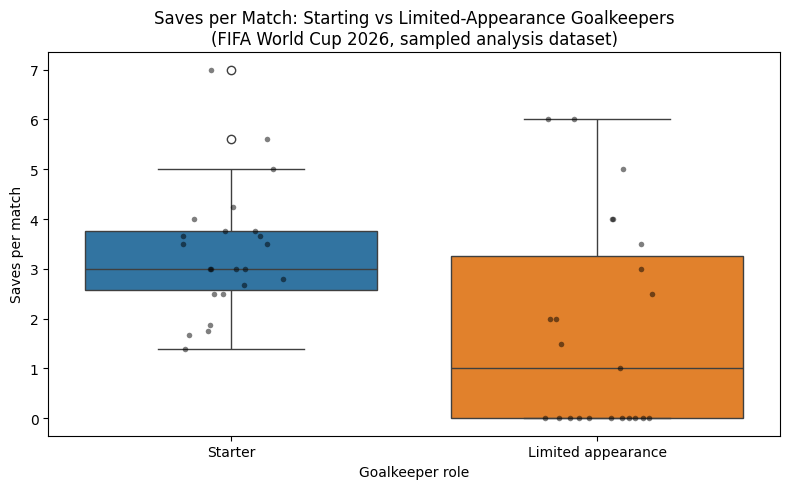

In [45]:
# visualize the distributions
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=analysis_sample, x="Role", y="SavesPerMatch",
    order=["Starter", "Limited appearance"],
    hue="Role", palette={"Starter": "#1f77b4", "Limited appearance": "#ff7f0e"}, legend=False,
    ax=ax,
)
sns.stripplot(
    data=analysis_sample, x="Role", y="SavesPerMatch",
    order=["Starter", "Limited appearance"],
    color="black", alpha=0.5, size=4, jitter=0.15, ax=ax,
)
# Set labels and title
ax.set_title("Saves per Match: Starting vs Limited-Appearance Goalkeepers\n(FIFA World Cup 2026, sampled analysis dataset)")
ax.set_xlabel("Goalkeeper role")
ax.set_ylabel("Saves per match")
plt.tight_layout()
plt.show()

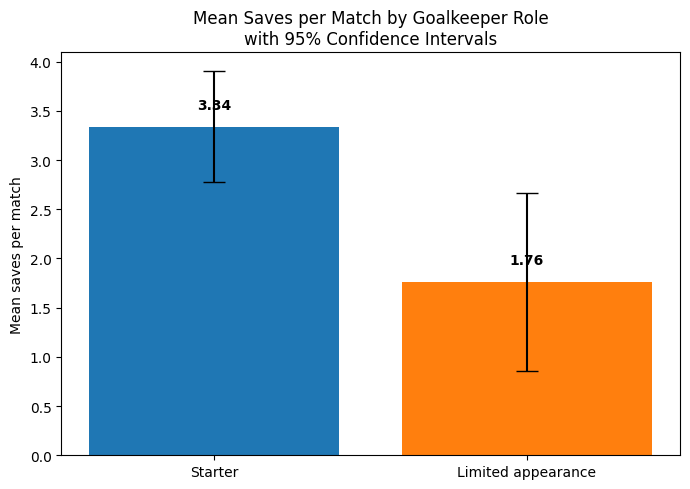

In [46]:
# Create a bar chart with confidence intervals
fig, ax = plt.subplots(figsize=(7, 5))

roles = ["Starter", "Limited appearance"]
group_means = [mean1, mean2]

# 95% CI half-widths calculated individually for each group's own mean (for the bar chart),
# using the same Welch-style approach applied consistently per group's own sample.
group_cis = []
for vals in [starter_vals, limited_vals]:
    n = len(vals)
    sem = vals.std(ddof=1) / np.sqrt(n)
    tcrit = stats.t.ppf(0.975, n - 1)
    group_cis.append(tcrit * sem)
# Create the bar chart
bars = ax.bar(roles, group_means, yerr=group_cis, capsize=8,
               color=["#1f77b4", "#ff7f0e"])
ax.set_title("Mean Saves per Match by Goalkeeper Role\nwith 95% Confidence Intervals")
ax.set_ylabel("Mean saves per match")
for bar, mean_val in zip(bars, group_means):
    ax.text(bar.get_x() + bar.get_width() / 2, mean_val + 0.15, f"{mean_val:.2f}",
            ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()

NameError: name 'os' is not defined

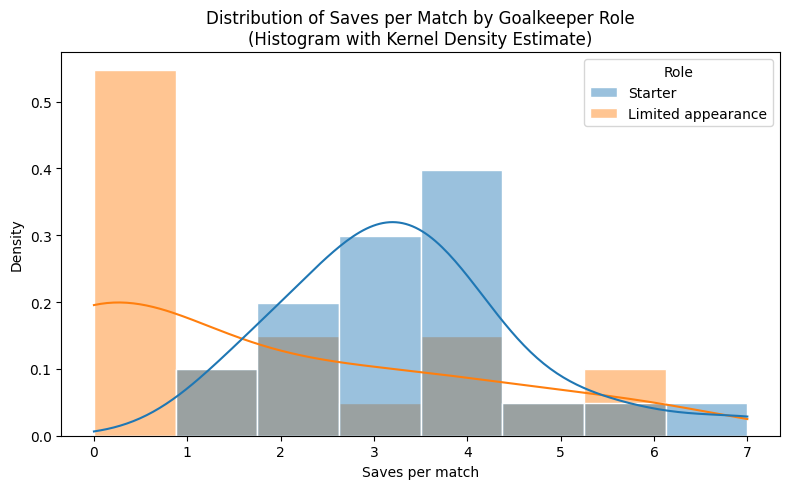

In [ ]:
import os

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=analysis_sample, x="SavesPerMatch", hue="Role", hue_order=["Starter", "Limited appearance"],
    kde=True, stat="density", common_norm=False, bins=8,
    palette={"Starter": "#1f77b4", "Limited appearance": "#ff7f0e"},
    alpha=0.45, edgecolor="white", ax=ax,
)

ax.set_title("Distribution of Saves per Match by Goalkeeper Role\n(Histogram with Kernel Density Estimate)")
ax.set_xlabel("Saves per match")
ax.set_ylabel("Density")
plt.tight_layout()
CHARTS_DIR = os.path.join(os.getcwd(), "charts")
os.makedirs(CHARTS_DIR, exist_ok=True)

plt.savefig(
    os.path.join(CHARTS_DIR, "03_histogram_kde_saves_per_match.png"),
    dpi=200,
    bbox_inches="tight"
)
plt.show()

Analytical Question
Do established Starting goalkeepers at the FIFA World Cup 2026 Record a significantly higher average number of saves per match than goalkeepers with only limited apperarances.




Conclusion 
